In [1]:
# pip install yfinance

In [2]:
import yfinance as yf
import matplotlib.pyplot as plt 
import plotly.express as px
# import cufflinks as cf
# from plotly.offline import init_notebook_mode, download_plotlyjs
# cf.go_offline(connected=True)
import pandas as pd
import numpy as np

import warnings 
warnings.filterwarnings('ignore')

In [3]:
stock_data = yf.download('AAPL',start='2024-01-01')
stock_data.head()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2024-01-02,184.734985,187.521338,182.993517,186.237618,82488700
2024-01-03,183.351746,184.973804,182.535736,183.321893,58414500
2024-01-04,181.023163,182.197403,179.998185,181.261983,71983600
2024-01-05,180.296722,181.869022,179.291652,181.102786,62303300
2024-01-08,184.655365,184.695178,180.615161,181.202281,59144500


 
1. **Price**:  
   - Represents the current market price of the asset (e.g., stock, cryptocurrency).
   - Can refer to the latest trading price or an adjusted price depending on the dataset.

2. **Close**:  
   - The final trading price of the asset at the end of the trading period (day, hour, minute, etc.).
   - Used as a key indicator in many trading strategies.

3. **High**:  
   - The highest price at which the asset was traded during the trading period.
   - Reflects the peak of the market activity within the timeframe.

4. **Low**:  
   - The lowest price at which the asset was traded during the trading period.
   - Highlights the minimum market activity within the timeframe.

5. **Open**:  
   - The price of the asset at the start of the trading period.
   - Helps establish the starting value for trend analysis.

6. **Volume**:  
   - The total number of shares or contracts traded during the period.
   - Indicates the level of market activity and liquidity.



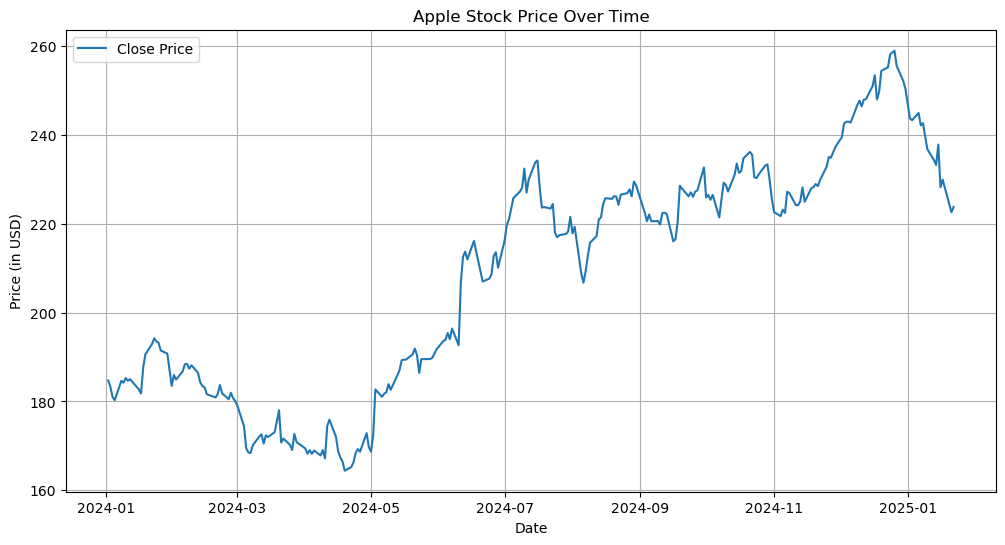

In [4]:
plt.figure(figsize=(12,6))
# plt.plot(stock_data.index,stock_data['Open'],label='Open Price')
plt.plot(stock_data.index,stock_data['Close'],label='Close Price')
plt.legend()
plt.title('Apple Stock Price Over Time')
plt.xlabel('Date')
plt.ylabel('Price (in USD)')
plt.grid()
plt.show()

# Classical Time Series Decomposition

In [5]:
from statsmodels.tsa.seasonal import seasonal_decompose
decomposition_additive = seasonal_decompose(stock_data['Close'],model='additive', period=30)

In [6]:
trend_additive = decomposition_additive.trend
seasonal_additive = decomposition_additive.seasonal
residual_additive = decomposition_additive.resid

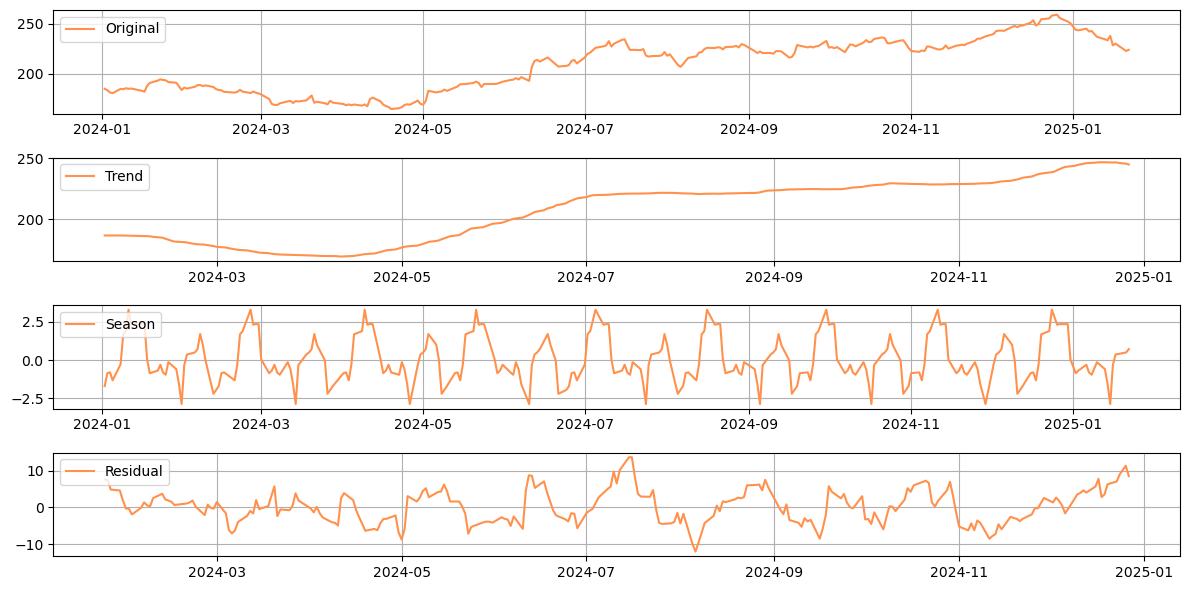

In [7]:
plt.figure(figsize=(12,6))
plt.subplot(411)
plt.plot(stock_data['Close'],label='Original',color='#FF914D')
plt.legend(loc='upper left')
plt.grid()
plt.subplot(412)
plt.plot(trend_additive,label='Trend',color='#FF914D')
plt.legend(loc='upper left')
plt.grid()
plt.subplot(413)
plt.plot(seasonal_additive,label='Season',color='#FF914D')
plt.legend(loc='upper left')
plt.grid()
plt.subplot(414)
plt.plot(residual_additive,label='Residual',color='#FF914D')
plt.legend(loc='upper left')
plt.tight_layout()
plt.grid()
plt.show()

In [8]:
stock_data.head()

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2024-01-02,184.734985,187.521338,182.993517,186.237618,82488700
2024-01-03,183.351746,184.973804,182.535736,183.321893,58414500
2024-01-04,181.023163,182.197403,179.998185,181.261983,71983600
2024-01-05,180.296722,181.869022,179.291652,181.102786,62303300
2024-01-08,184.655365,184.695178,180.615161,181.202281,59144500


# STL Decomposition using LOESS

In [9]:
from statsmodels.tsa.seasonal import STL

In [10]:
# stl = STL(stock_data['Close'],period=30)

In [11]:
close_series = stock_data['Close'].squeeze()
# Perform STL decomposition
stl = STL(close_series, period=30)
result = stl.fit()

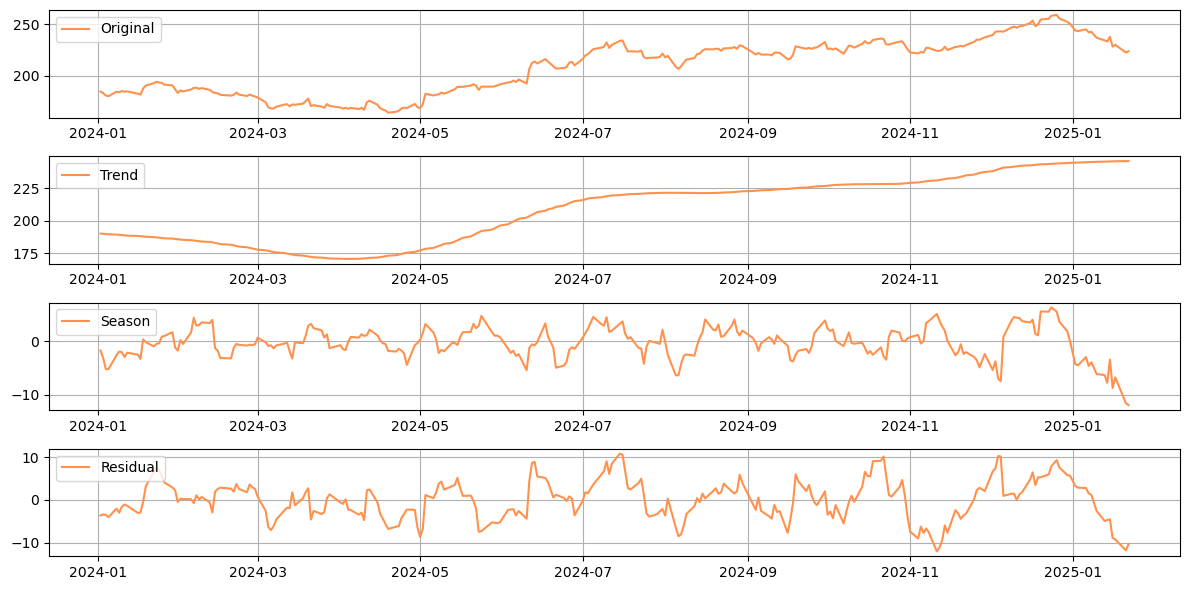

In [12]:
plt.figure(figsize=(12,6))
plt.subplot(411)
plt.plot(result.observed, label='Original', color='#FF914D')
plt.legend(loc='upper left')
plt.grid()
plt.subplot(412)
plt.plot(result.trend, label='Trend', color='#FF914D')
plt.legend(loc='upper left')
plt.grid()
plt.subplot(413)
plt.plot(result.seasonal, label='Season', color='#FF914D')
plt.legend(loc='upper left')
plt.grid()
plt.subplot(414)
plt.plot(result.resid, label='Residual', color='#FF914D')
plt.legend(loc='upper left')
plt.tight_layout()
plt.grid()
plt.show()

Hello, I'm **Anshum Banga**, a passionate **Data Scientist** with expertise in **Time Series Analysis**, **Machine Learning**, and **Deep Learning**. I enjoy teaching and sharing knowledge, and I regularly conduct sessions to help others excel in the field of data science.

Stay connected for more insightful content on **LinkedIn** and **GitHub**:  
- [LinkedIn](https://www.linkedin.com/in/anshumbanga)  
- [GitHub](https://www.github.com/anshumbanga)